In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report


df = pd.read_parquet('../../dataset/data.parquet', engine='fastparquet')
df = df[df['Desired_Savings'] > 0].copy()


df['perc_nao_essenciais'] = (df['Eating_Out'] + df['Entertainment']) / df['Income']
df['perc_emprestimo'] = df['Loan_Repayment'] / df['Income']
df['Vulnerable'] = ((df['perc_emprestimo'] > 0.10).astype(int) + 
                    (df['perc_nao_essenciais'] > 0.085).astype(int) + 
                    ((df['Disposable_Income'] - df['Desired_Savings']) / df['Income'] < 0.10).astype(int) + 
                    (df['Potential_Savings_Groceries'] / df['Income'] > 0.08).astype(int) >= 2).astype(int)


df['Rent_Ratio'] = df['Rent'] / df['Income']
df['Healthcare_Ratio'] = df['Healthcare'] / df['Income']
df['Education_Ratio'] = df['Education'] / df['Income']
df['Savings_Goal_Ratio'] = df['Desired_Savings'] / df['Income']


features_percentuais = [
    'Age', 
    'Dependents', 
    'Rent_Ratio', 
    'Healthcare_Ratio', 
    'Education_Ratio', 
    'Savings_Goal_Ratio', 
    'perc_emprestimo' 
]

X = df[features_percentuais]
y = df['Vulnerable']

# 3. Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

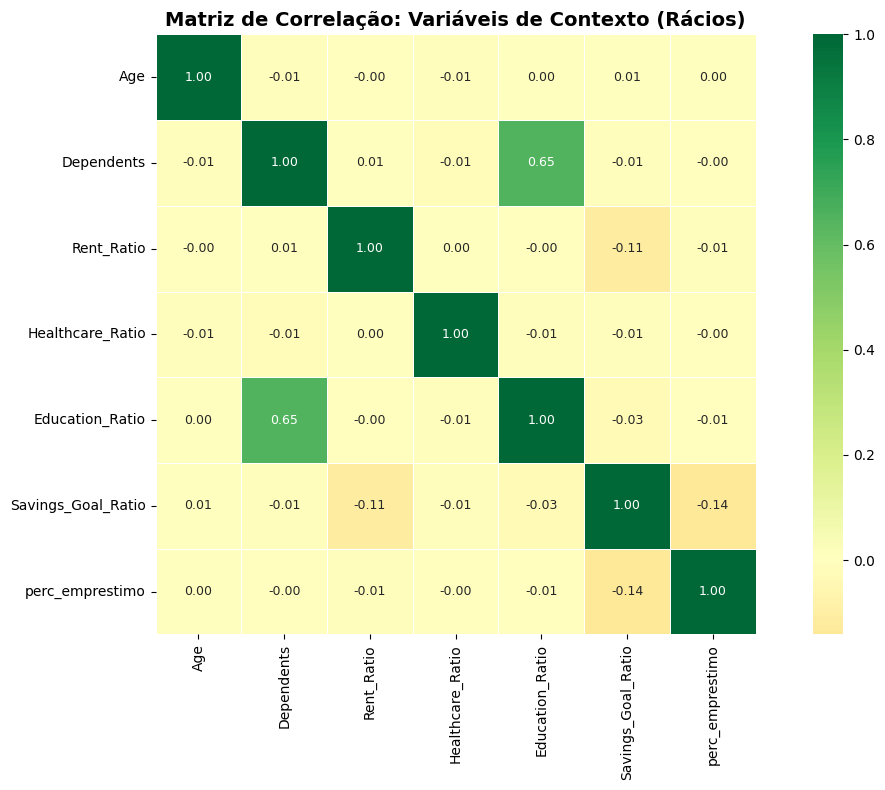


 ALERTA DE MULTICOLINEARIDADE (Correlação > 0.7 ou < -0.7) 
------------------------------------------------------------


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparação dos dados para a correlação
# Usamos a mesma lista de 'features_percentuais' que alimenta o modelo
features_percentuais = [
    'Age', 'Dependents', 'Rent_Ratio', 'Healthcare_Ratio', 
    'Education_Ratio', 'Savings_Goal_Ratio', 'perc_emprestimo'
]

# Adicionamos o 'Vulnerable' para ver como cada rácio se correlaciona com o alvo
X_corr = df[features_percentuais]
corr_matrix = X_corr.corr()

# 2. Plotagem do Heatmap (mesma estilização solicitada)
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title('Matriz de Correlação: Variáveis de Contexto (Rácios)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. Alerta de Multicolinearidade
print("\n ALERTA DE MULTICOLINEARIDADE (Correlação > 0.7 ou < -0.7) ")
print("------------------------------------------------------------")
for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if col != row and abs(corr_matrix.loc[row, col]) > 0.7:
            # Garante que só imprimimos uma vez (evita duplicatas da matriz simétrica)
            if list(corr_matrix.columns).index(row) > list(corr_matrix.columns).index(col):
                print(f"  {row} ↔ {col}: {corr_matrix.loc[row, col]:.2f}")

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, roc_auc_score

# 1. Preparação de pesos unificada
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
ratio = n_neg / n_pos 

# 2. Definição dos modelos
# O SVM recebe um pipeline com StandardScaler pois ele precisa de dados normalizados
modelos = {
    'Regressão Logística': LogisticRegression(random_state=42, class_weight={0: 1, 1: ratio * 0.8}, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight={0: 1, 1: ratio * 0.8}, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, subsample=0.8),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=ratio * 0.8, min_child_weight=5, max_depth=5),
    'SVM': make_pipeline(StandardScaler(), SVC(probability=True, random_state=42, class_weight={0: 1, 1: ratio * 0.8})),
    'CatBoost': CatBoostClassifier(random_state=42, class_weights=[1, ratio * 0.8], verbose=0)
}

# 3. Treino e Avaliação
print(f"🔄 Treinando {len(modelos)} algoritmos de alta performance...\n")

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    # Cálculo de AUC-ROC (todos possuem predict_proba)
    y_prob = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
        
    print(f"{'='*60}")
    print(f" ALGORITMO: {nome}")
    print(f" AUC-ROC: {auc:.4f}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred, target_names=['Seguro', 'Vulnerável']))
    print("\n")

🔄 Treinando 6 algoritmos de alta performance...

 ALGORITMO: Regressão Logística
 AUC-ROC: 0.9645
              precision    recall  f1-score   support

      Seguro       0.97      0.89      0.93      3158
  Vulnerável       0.68      0.91      0.78       820

    accuracy                           0.89      3978
   macro avg       0.83      0.90      0.85      3978
weighted avg       0.91      0.89      0.90      3978



 ALGORITMO: Random Forest
 AUC-ROC: 0.9700
              precision    recall  f1-score   support

      Seguro       0.95      0.97      0.96      3158
  Vulnerável       0.89      0.81      0.85       820

    accuracy                           0.94      3978
   macro avg       0.92      0.89      0.91      3978
weighted avg       0.94      0.94      0.94      3978



 ALGORITMO: Gradient Boosting
 AUC-ROC: 0.9741
              precision    recall  f1-score   support

      Seguro       0.96      0.97      0.97      3158
  Vulnerável       0.88      0.85      0.86  

In [7]:
from sklearn.metrics import classification_report
import pandas as pd

def formatar_resultado(nome_modelo, y_test, y_pred):
    report = classification_report(
        y_test, y_pred,
        target_names=['Seguro', 'Vulnerável'],
        output_dict=True
    )

    def fmt(v):
        return f"{v:.3f}".replace('.', ',')

    rows = [
        {
            'Modelo': nome_modelo,
            'Métrica': 'Precisão',
            'Seguro (0)': fmt(report['Seguro']['precision']),
            'Vulnerável (1)': fmt(report['Vulnerável']['precision']),
            'Média': fmt(report['macro avg']['precision']),
            'Média Ponderada': fmt(report['weighted avg']['precision']),
        },
        {
            'Modelo': '',
            'Métrica': 'Recall',
            'Seguro (0)': fmt(report['Seguro']['recall']),
            'Vulnerável (1)': fmt(report['Vulnerável']['recall']),
            'Média': fmt(report['macro avg']['recall']),
            'Média Ponderada': fmt(report['weighted avg']['recall']),
        },
        {
            'Modelo': '',
            'Métrica': 'F1-Score',
            'Seguro (0)': fmt(report['Seguro']['f1-score']),
            'Vulnerável (1)': fmt(report['Vulnerável']['f1-score']),
            'Média': fmt(report['macro avg']['f1-score']),
            'Média Ponderada': fmt(report['weighted avg']['f1-score']),
        },
        {
            'Modelo': '',
            'Métrica': 'Suporte',
            'Seguro (0)': str(int(report['Seguro']['support'])),
            'Vulnerável (1)': str(int(report['Vulnerável']['support'])),
            'Média': str(int(report['Seguro']['support'] + report['Vulnerável']['support'])),
            'Média Ponderada': '—',
        },
        {
            'Modelo': '',
            'Métrica': 'Acurácia',
            'Seguro (0)': '—',
            'Vulnerável (1)': '—',
            'Média': fmt(report['accuracy']),
            'Média Ponderada': '—',
        },
    ]
    return pd.DataFrame(rows)


todas_tabelas = []
for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    todas_tabelas.append(formatar_resultado(nome, y_test, y_pred))

resultado_final = pd.concat(todas_tabelas, ignore_index=True)
resultado_final = resultado_final.set_index(['Modelo', 'Métrica'])

display(resultado_final.style.set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
    {'selector': 'td', 'props': [('text-align', 'center')]},
]))

In [8]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier

modelo_gb_cv = GradientBoostingClassifier(random_state=42, subsample=0.8)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv = cross_validate(modelo_gb_cv, X, y,
                               cv=skf, scoring=['recall', 'precision'])

recall_medio = resultados_cv['test_recall'].mean()
recall_std   = resultados_cv['test_recall'].std()

precisao_media = resultados_cv['test_precision'].mean()
precisao_std   = resultados_cv['test_precision'].std()

print("\n" + "="*50)
print("RESULTADO DO CROSS-VALIDATION (Gradient Boosting)")
print("="*50)
print(f"🎯 Recall Médio:   {recall_medio:.3f} (+/- {recall_std:.3f})")
print(f"🎯 Precisão Média: {precisao_media:.3f} (+/- {precisao_std:.3f})")
print("="*50)



RESULTADO DO CROSS-VALIDATION (Gradient Boosting)
🎯 Recall Médio:   0.832 (+/- 0.014)
🎯 Precisão Média: 0.900 (+/- 0.012)


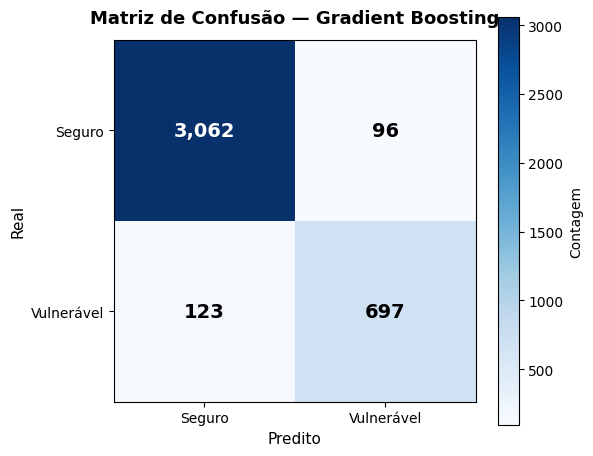

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_pred_gb = modelos['Gradient Boosting'].predict(X_test)
cm = confusion_matrix(y_test, y_pred_gb)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, label='Contagem')

ax.set_title('Matriz de Confusão — Gradient Boosting', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Predito', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Seguro', 'Vulnerável'], fontsize=10)
ax.set_yticklabels(['Seguro', 'Vulnerável'], fontsize=10)

thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}',
                ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.savefig('matriz_confusao_gb.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\USER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


              feature  importancia
1          Dependents     0.028804
0                 Age     0.032235
3    Healthcare_Ratio     0.074756
4     Education_Ratio     0.467086
5  Savings_Goal_Ratio     0.581709
2          Rent_Ratio     0.977759
6     perc_emprestimo     2.358055


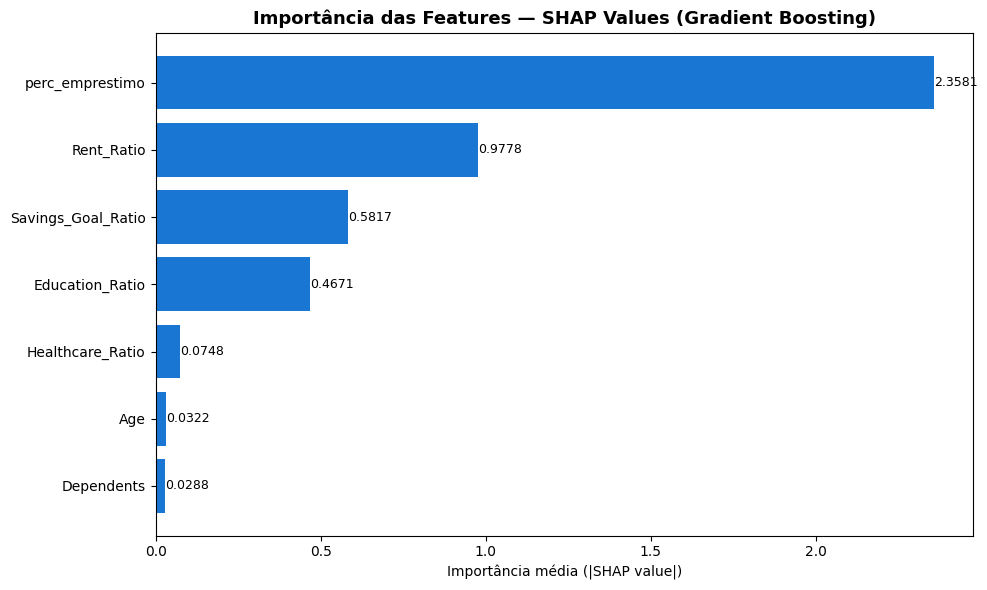

✅ Gráfico SHAP salvo!


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

modelo_gb = modelos['Gradient Boosting']

explainer = shap.TreeExplainer(modelo_gb)
shap_values = explainer.shap_values(X_test)

sv = shap_values

mean_shap = np.abs(sv).mean(axis=0)
shap_df = pd.DataFrame({
    'feature': features_percentuais,
    'importancia': mean_shap
}).sort_values('importancia', ascending=True)

print(shap_df)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(shap_df['feature'], shap_df['importancia'], color='#1976d2')
ax.set_title('Importância das Features — SHAP Values (Gradient Boosting)', fontweight='bold', fontsize=13)
ax.set_xlabel('Importância média (|SHAP value|)')

for i, v in enumerate(shap_df['importancia']):
    ax.text(v + 0.0005, i, f"{v:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('shap_importancia_gb.png', dpi=150)
plt.show()
print("✅ Gráfico SHAP salvo!")

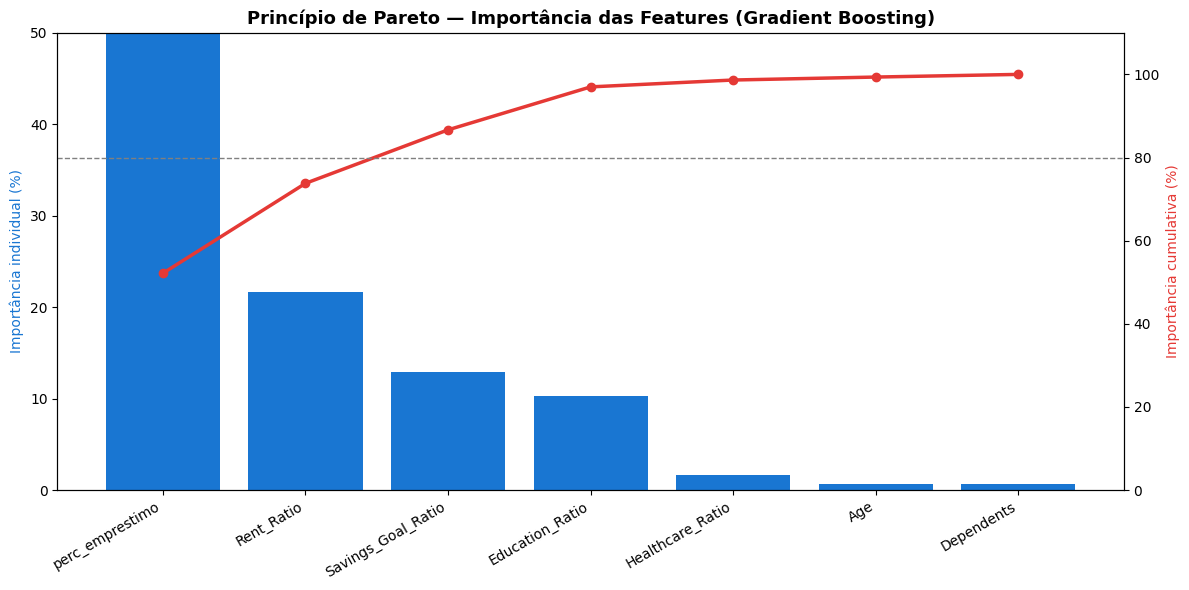

✅ Gráfico de Pareto salvo!


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sv = shap_values
mean_shap = np.abs(sv).mean(axis=0)

shap_df = pd.DataFrame({
    'feature': features_percentuais,
    'importancia': mean_shap
}).sort_values('importancia', ascending=False)

shap_df['importancia_pct'] = shap_df['importancia'] / shap_df['importancia'].sum() * 100
shap_df['cumulativo'] = shap_df['importancia_pct'].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(shap_df['feature'], shap_df['importancia_pct'], color='#1976d2', label='Importância %')
ax1.set_ylabel('Importância individual (%)', color='#1976d2')
ax1.set_xticks(range(len(shap_df['feature'])))
ax1.set_xticklabels(shap_df['feature'], rotation=30, ha='right')
ax1.set_ylim(0, 50)

ax2 = ax1.twinx()
ax2.plot(shap_df['feature'], shap_df['cumulativo'], color='#e53935',
         marker='o', linewidth=2.5, label='Cumulativo %')
ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1, label='80%')
ax2.set_ylabel('Importância cumulativa (%)', color='#e53935')
ax2.set_ylim(0, 110)

plt.title('Princípio de Pareto — Importância das Features (Gradient Boosting)', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('pareto_features_gb.png', dpi=150)
plt.show()
print("✅ Gráfico de Pareto salvo!")

In [12]:
import pandas as pd
import numpy as np

modelo_gb = modelos['Gradient Boosting']

# Rodando o modelo em toda a base (sem escala — GBM não precisa)
X_completo = df[features_percentuais]
df['probabilidade_risco'] = modelo_gb.predict_proba(X_completo)[:, 1]

def classificar_risco(prob):
    if prob < 0.30:
        return 'Baixo'
    elif prob < 0.60:
        return 'Médio'
    else:
        return 'Alto'

df['nivel_risco'] = df['probabilidade_risco'].apply(classificar_risco)

segmentacao = df.groupby('nivel_risco').agg(
    clientes=('Income', 'count'),
    renda_media=('Income', 'mean'),
    emprestimo_medio=('Loan_Repayment', 'mean'),
    prob_media=('probabilidade_risco', 'mean')
).reindex(['Baixo', 'Médio', 'Alto'])

segmentacao['pct_base'] = (segmentacao['clientes'] / len(df) * 100).round(1)
segmentacao['exposicao_mensal'] = segmentacao['clientes'] * segmentacao['emprestimo_medio']

print("=" * 65)
print("  SEGMENTAÇÃO DE CLIENTES POR NÍVEL DE RISCO (Gradient Boosting)")
print("=" * 65)
for nivel in ['Baixo', 'Médio', 'Alto']:
    row = segmentacao.loc[nivel]
    print(f"\n🔹 Risco {nivel}:")
    print(f"   Clientes:            {int(row['clientes']):,}")
    print(f"   % da base:           {row['pct_base']}%")
    print(f"   Prob. média:         {row['prob_media']*100:.1f}%")
    print(f"   Empréstimo médio:    R$ {row['emprestimo_medio']:,.0f}")
    print(f"   Exposição mensal:    R$ {row['exposicao_mensal']:,.0f}")

alto_risco = segmentacao.loc['Alto']
exposicao_total = alto_risco['exposicao_mensal']
economia_30pct = exposicao_total * 0.30

print("\n" + "=" * 65)
print("  IMPACTO FINANCEIRO — GRUPO DE ALTO RISCO")
print("=" * 65)
print(f"\n  Clientes em alto risco:     {int(alto_risco['clientes']):,}")
print(f"  Exposição mensal total:     R$ {exposicao_total:,.0f}")
print(f"  Economia potencial (30%):   R$ {economia_30pct:,.0f}")
print(f"\n  * Estimativa conservadora: prevenção de 30% das inadimplências")
print(f"    com ação antecipada (contato, renegociação, limite)")

  SEGMENTAÇÃO DE CLIENTES POR NÍVEL DE RISCO (Gradient Boosting)

🔹 Risco Baixo:
   Clientes:            15,537
   % da base:           78.1%
   Prob. média:         3.5%
   Empréstimo médio:    R$ 705
   Exposição mensal:    R$ 10,947,507

🔹 Risco Médio:
   Clientes:            761
   % da base:           3.8%
   Prob. média:         43.6%
   Empréstimo médio:    R$ 4,365
   Exposição mensal:    R$ 3,321,435

🔹 Risco Alto:
   Clientes:            3,590
   % da base:           18.1%
   Prob. média:         90.5%
   Empréstimo médio:    R$ 7,182
   Exposição mensal:    R$ 25,781,901

  IMPACTO FINANCEIRO — GRUPO DE ALTO RISCO

  Clientes em alto risco:     3,590
  Exposição mensal total:     R$ 25,781,901
  Economia potencial (30%):   R$ 7,734,570

  * Estimativa conservadora: prevenção de 30% das inadimplências
    com ação antecipada (contato, renegociação, limite)


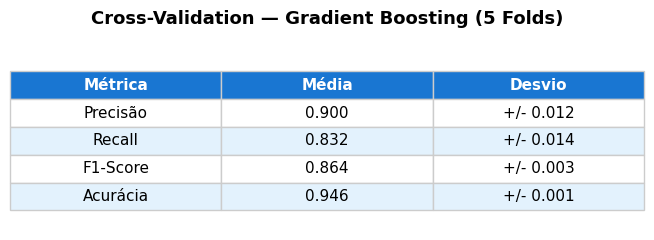

In [13]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import pandas as pd

modelo_gb_cv = GradientBoostingClassifier(random_state=42, subsample=0.8)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_cv = cross_validate(
    modelo_gb_cv, X, y,
    cv=skf,
    scoring=['precision', 'recall', 'f1', 'accuracy']
)

dados = {
    'Métrica':  ['Precisão', 'Recall', 'F1-Score', 'Acurácia'],
    'Média':    [f"{resultados_cv[f'test_{k}'].mean():.3f}" for k in ['precision', 'recall', 'f1', 'accuracy']],
    'Desvio':   [f"+/- {resultados_cv[f'test_{k}'].std():.3f}" for k in ['precision', 'recall', 'f1', 'accuracy']],
}

df_cv = pd.DataFrame(dados)

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.axis('off')

tabela = ax.table(
    cellText=df_cv.values,
    colLabels=df_cv.columns,
    cellLoc='center',
    loc='center'
)

tabela.auto_set_font_size(False)
tabela.set_fontsize(11)
tabela.scale(1.4, 1.8)

for (row, col), cell in tabela.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1976d2')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#e3f2fd')
    else:
        cell.set_facecolor('white')
    cell.set_edgecolor('#cccccc')

ax.set_title('Cross-Validation — Gradient Boosting (5 Folds)',
             fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('cv_tabela_gb.png', dpi=150, bbox_inches='tight')
plt.show()

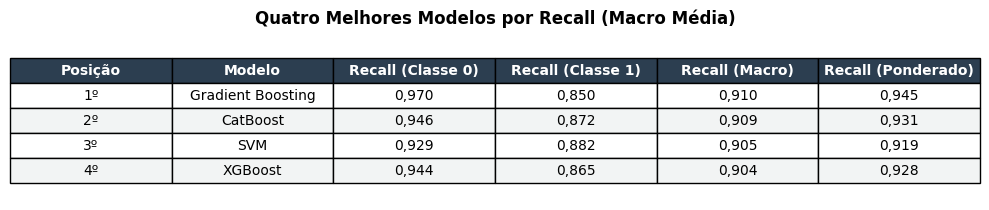

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados dos 4 melhores modelos por recall macro
dados = {
    "Posição": ["1º", "2º", "3º", "4º"],
    "Modelo": ["Gradient Boosting", "CatBoost", "SVM", "XGBoost"],
    "Recall (Classe 0)": [0.970, 0.946, 0.929, 0.944],
    "Recall (Classe 1)": [0.850, 0.872, 0.882, 0.865],
    "Recall (Macro)": [0.910, 0.909, 0.905, 0.904],
    "Recall (Ponderado)": [0.945, 0.931, 0.919, 0.928],
}

df = pd.DataFrame(dados)

# Formata os números com 3 casas decimais e vírgula decimal (padrão brasileiro)
df_fmt = df.copy()
for col in df_fmt.columns[2:]:
    df_fmt[col] = df_fmt[col].map(lambda x: f"{x:.3f}".replace(".", ","))

# Renderiza a tabela como figura
fig, ax = plt.subplots(figsize=(10, 2.2))
ax.axis("off")

tabela = ax.table(
    cellText=df_fmt.values,
    colLabels=df_fmt.columns,
    cellLoc="center",
    loc="center",
)
tabela.auto_set_font_size(False)
tabela.set_fontsize(10)
tabela.scale(1, 1.6)

# Estiliza o cabeçalho
for j in range(len(df_fmt.columns)):
    cell = tabela[0, j]
    cell.set_facecolor("#2C3E50")
    cell.set_text_props(color="white", fontweight="bold")

# Linhas alternadas (zebra)
for i in range(1, len(df_fmt) + 1):
    for j in range(len(df_fmt.columns)):
        if i % 2 == 0:
            tabela[i, j].set_facecolor("#F2F4F4")

plt.title("Quatro Melhores Modelos por Recall (Macro Média)",
          fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("tabela_recall.png", dpi=300, bbox_inches="tight")
plt.show()